In [34]:
#!!!!!!!!!!!!! ONLY RUN THIS CODE WHEN YOU DON'T HAVE THE CSV !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

from scipy.io import arff
import pandas as pd

# Load the arff file
data, meta = arff.loadarff('fps-in-video-games.arff')

# Convert to a pandas DataFrame
df = pd.DataFrame(data)
# df.to_csv('fps-in-video-games.csv', index=False)

In [35]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt






In [36]:

# df = pd.read_csv('fps-in-video-games.csv')
print(df.shape)
df.head()

(425833, 45)


,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,...,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',70.0
1,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',230.0
2,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',250.0
3,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',300.0
4,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,896.0,56.0,61600.0,2080.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',200.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  object 
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  object 
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors     19

In [38]:
# Convert byte to string
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False)


In [39]:
df = df.rename(columns={"GpuBus nterface": "GpuBusInterface"})

In [40]:
missing = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
GpuNumberOfExecutionUnits,412935,96.971113
GpuNumberOfComputeUnits,357107,83.860809
CpuNumberOfTransistors,226039,53.081607
CpuDieSize,202534,47.561838
GpuBandwidth,15441,3.626069
GpuMemorySize,15441,3.626069
GpuMemoryBus,15441,3.626069
GpuNumberOfTransistors,11539,2.709748
GpuDieSize,11196,2.629200
CpuCacheL3,5055,1.187085


In [41]:
cols_to_drop = missing_percent[missing_percent > 10].index
print("Dropped columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Dropped columns: Index(['CpuDieSize', 'CpuNumberOfTransistors', 'GpuNumberOfComputeUnits',
       'GpuNumberOfExecutionUnits'],
      dtype='object')


In [42]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [43]:
# Drop duplicate
df = df.drop_duplicates()

# Drop kolom yang tidak penting (opsional)
df = df.drop(columns=["CpuName", "GpuName"], errors='ignore')

In [44]:
Q1 = df["FPS"].quantile(0.25)
Q3 = df["FPS"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["FPS"] >= Q1 - 1.5*IQR) & (df["FPS"] <= Q3 + 1.5*IQR)]

In [45]:
# check the spread for game name
print(df["GameName"].value_counts())

# Slicing the dataset to only include games with at less than 10000 samples
# df = df[df["GameName"].isin(df["GameName"].value_counts()[df["GameName"].value_counts() < 10000].index)]

GameName
counterStrikeGlobalOffensive    27021
fortnite                        22811
playerUnknownsBattlegrounds     21256
overwatch                       18789
grandTheftAuto5                 17627
leagueOfLegends                 15248
battlefield1                     9681
apexLegends                      8262
dota2                            6783
worldOfTanks                     6541
battlefield4                     5809
minecraft                        4875
callOfDutyBlackOps4              4097
rust                             3119
arkSurvivalEvolved               2915
rocketLeague                     2444
callOfDutyWW2                    1026
pathOfExile                      1026
destiny2                         1026
radicalHeights                   1026
seaOfThieves                     1026
frostpunk                        1026
totalWar3Kingdoms                1026
airMechStrike                    1026
battletech                       1026
farCry5                          1026
rai

In [46]:

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])


In [47]:
X = df.drop("FPS", axis=1)
y = df["FPS"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Before PCA:", X_train_scaled.shape)
print("After PCA :", X_train_pca.shape)


X_train_no_pca = X_train_scaled
X_test_no_pca = X_test_scaled

Before PCA: (153312, 38)
After PCA : (153312, 18)


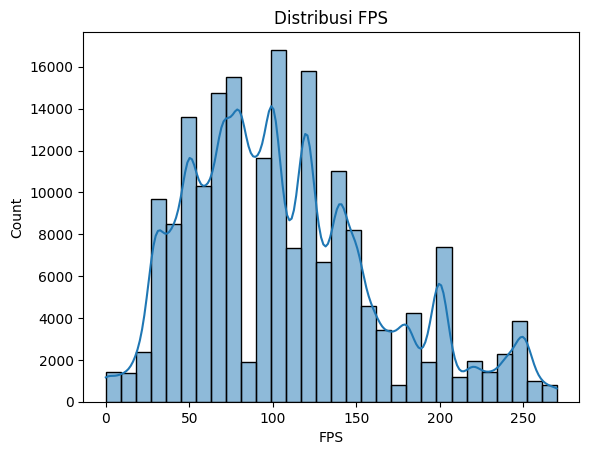

In [48]:
sns.histplot(df["FPS"], bins=30, kde=True)
plt.title("Distribusi FPS")
plt.show()

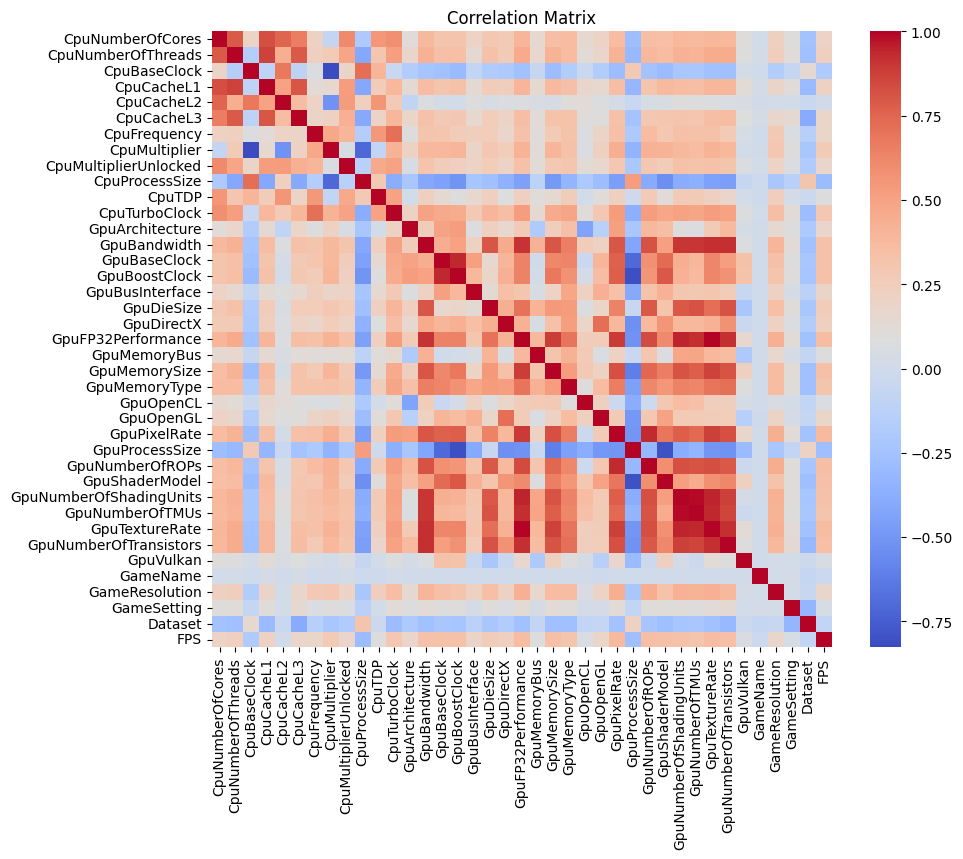

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

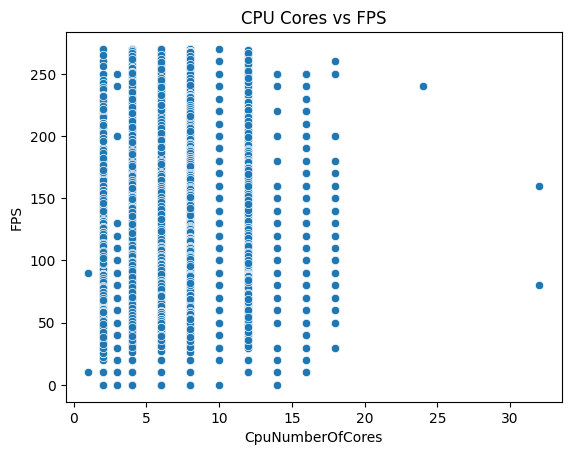

In [50]:
sns.scatterplot(x=df["CpuNumberOfCores"], y=df["FPS"])
plt.title("CPU Cores vs FPS")
plt.show()

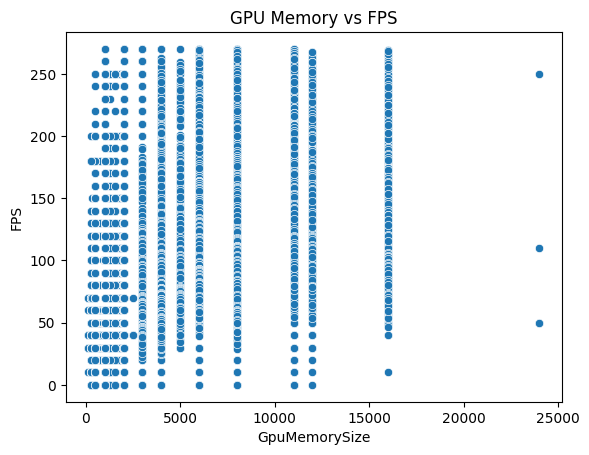

In [51]:
sns.scatterplot(x=df["GpuMemorySize"], y=df["FPS"])
plt.title("GPU Memory vs FPS")
plt.show()

<Axes: xlabel='GameResolution', ylabel='FPS'>

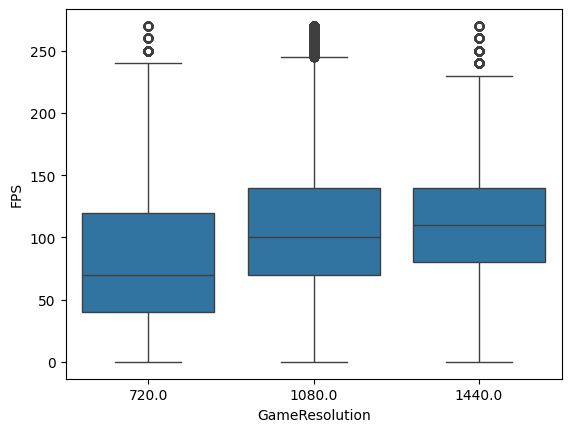

In [52]:
sns.boxplot(x=df["GameResolution"], y=df["FPS"])


In [53]:
def evaluate_model(y_true, y_pred, model_name=None):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    if model_name is not None:
        print(f"\n{model_name}")

    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [54]:
lr_pca = LinearRegression()

lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = lr_pca.predict(X_test_pca)

print("Linear Regression WITH PCA")
evaluate_model(y_test, y_pred_lr_pca)


lr_no_pca = LinearRegression()

lr_no_pca.fit(X_train_no_pca, y_train)

y_pred_lr_no_pca = lr_no_pca.predict(X_test_no_pca)

print("\nLinear Regression WITHOUT PCA")
evaluate_model(y_test, y_pred_lr_no_pca)

Linear Regression WITH PCA
RMSE: 51.81095071231232
MAE : 40.69180094101198
R2  : 0.18396054313125443

Linear Regression WITHOUT PCA
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.1889138409237645


{'RMSE': np.float64(51.65346709376512),
 'MAE': 40.55497557495813,
 'R2': 0.1889138409237645}

In [55]:

# =========================
# BASELINE ANN WITHOUT PCA
# =========================
inputs_no_pca = keras.Input(shape=(X_train_no_pca.shape[1],))

x = layers.Dense(64, activation='relu')(inputs_no_pca)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1)(x)

baseline_model_no_pca = keras.Model(
    inputs=inputs_no_pca,
    outputs=outputs
)

baseline_model_no_pca.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_no_pca = baseline_model_no_pca.fit(
    X_train_no_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_baseline_no_pca = baseline_model_no_pca.predict(X_test_no_pca)

Epoch 1/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 3075.2036 - mae: 42.7748 - val_loss: 2676.2527 - val_mae: 40.5179
Epoch 2/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2635.0125 - mae: 40.1788 - val_loss: 2568.8687 - val_mae: 39.6279
Epoch 3/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2460.6826 - mae: 38.7808 - val_loss: 2355.7920 - val_mae: 38.3986
Epoch 4/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 2264.9111 - mae: 37.0844 - val_loss: 2218.4473 - val_mae: 36.4611
Epoch 5/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2179.1304 - mae: 36.2269 - val_loss: 2156.9758 - val_mae: 36.0259
Epoch 6/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2126.4463 - mae: 35.6803 - val_loss: 2134.8215 - val_mae: 35.6392
Epoch 7/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2093.3650 - mae: 35.3324 - val_loss: 2094.5530 - val_mae: 35.0890
Epoch 8/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2066.8137 - mae: 35.0504 - val_los

In [56]:
# =========================
# BASELINE ANN WITH PCA
# =========================
inputs_pca = keras.Input(shape=(X_train_pca.shape[1],))

x = layers.Dense(64, activation='relu')(inputs_pca)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1)(x)

baseline_model_pca = keras.Model(
    inputs=inputs_pca,
    outputs=outputs
)

baseline_model_pca.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_pca = baseline_model_pca.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_baseline_pca = baseline_model_pca.predict(X_test_pca)


Epoch 1/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 3079.2339 - mae: 42.8304 - val_loss: 2685.0466 - val_mae: 40.5861
Epoch 2/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2657.5095 - mae: 40.3861 - val_loss: 2666.9731 - val_mae: 40.0909
Epoch 3/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2616.7019 - mae: 40.0296 - val_loss: 2544.0515 - val_mae: 39.2160
Epoch 4/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2360.1255 - mae: 37.8854 - val_loss: 2259.3225 - val_mae: 37.0122
Epoch 5/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2212.0942 - mae: 36.5492 - val_loss: 2201.9216 - val_mae: 36.6818
Epoch 6/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2162.0496 - mae: 36.0462 - val_loss: 2164.2993 - val_mae: 35.6531
Epoch 7/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2128.6443 - mae: 35.7087 - val_loss: 2136.8044 - val_mae: 35.6128
Epoch 8/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2097.0513 - mae: 35.3657 - val_los

In [59]:
print("Linear Regression WITH PCA")
evaluate_model(y_test, y_pred_lr_pca)

print("\nLinear Regression WITHOUT PCA")
evaluate_model(y_test, y_pred_lr_no_pca)

pca_results = evaluate_model(
    y_test,
    y_pred_baseline_pca,
    "Baseline ANN (PCA)"
)

non_pca_results = evaluate_model(
    y_test,
    y_pred_baseline_no_pca,
    "Baseline ANN (No PCA)"
)

Linear Regression WITH PCA
RMSE: 51.81095071231232
MAE : 40.69180094101198
R2  : 0.18396054313125443

Linear Regression WITHOUT PCA
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.1889138409237645

Baseline ANN (PCA)
RMSE: 41.84855424792171
MAE : 31.40189217587424
R2  : 0.46761114802405446

Baseline ANN (No PCA)
RMSE: 41.98242988962293
MAE : 31.51160087992362
R2  : 0.46419942186624374


In [60]:
if non_pca_results["R2"] > pca_results["R2"]:
    USE_PCA = False
    print("\nNon-PCA performs better.")
else:
    USE_PCA = True
    print("\nPCA performs better.")


PCA performs better.


In [ ]:
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# lr_cv = cross_val_score(lr, X_train_pca, y_train, cv=kf, scoring='r2')

# print("LR CV R2:", lr_cv.mean())


In [ ]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

if non_pca_results["R2"] > pca_results["R2"]:

    USE_PCA = False

    X_train_model = X_train_no_pca
    X_test_model = X_test_no_pca

    print("\nUsing NON-PCA dataset for tuning.")

else:

    USE_PCA = True

    X_train_model = X_train_pca
    X_test_model = X_test_pca

    print("\nUsing PCA dataset for tuning.")

def build_model(hp):

    num_units = hp.Choice(
        "num_units",
        [64, 128]
    )

    dropout_rate = hp.Choice(
        "dropout_rate",
        [0.1, 0.2, 0.3]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [1e-3, 5e-4]
    )

    inputs = keras.Input(
        shape=(X_train_model.shape[1],)
    )

    x = layers.Dense(
        num_units,
        activation="relu"
    )(inputs)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Dense(
        num_units // 2,
        activation="relu"
    )(x)

    outputs = layers.Dense(1)(x)

    model = keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    directory="tuning",
    project_name=f"{'pca' if USE_PCA else 'non_pca'}_regression",
    overwrite=True
)

tuner.search(
    X_train_model,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=kt.engine.hyperparameters.HyperParameters().Choice(
        "batch_size",
        [32, 64]
    ),
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)


Trial 2 Complete [00h 21m 59s]
val_loss: 1599.587646484375

Best val_loss So Far: 1599.587646484375
Total elapsed time: 00h 43m 52s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
128               |256               |num_units
0.1               |0.4               |dropout_rate
0.0005            |0.0005            |learning_rate

Epoch 1/100
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 3202.0825 - mae: 43.5748 - val_loss: 2703.3237 - val_mae: 40.4670 - learning_rate: 5.0000e-04
Epoch 2/100
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2689.1460 - mae: 40.5868 - val_loss: 2674.7942 - val_mae: 40.4572 - learning_rate: 5.0000e-04
Epoch 3/100
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2665.3606 - mae: 40.4096 - val_loss: 2649.2185 - val_mae: 39.9700 - learning_rate: 5.0000e-04
Epoch 4/100
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2619.2957 - mae: 39.9997 - val_loss: 2561.8530 - val_mae: 39.6944 - learning_rate: 5.0000e-04
Epoc

In [ ]:
best_result = tuner.results_summary()
best_result

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Model Summary")
best_model.summary()
print("\nBest Hyperparameters")
print(best_hp.values)


In [ ]:

y_pred_best = best_model.predict(X_test_pca)
print("\nBest ANN Performance")
evaluate_model(y_test, y_pred_best)




In [ ]:
# =========================
# XGBOOST REGRESSOR
# =========================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Performance")
evaluate_model(y_test, y_pred_xgb)